# Telco Customer Churn Interpretability Analysis

In this notebook, the Telco Customer Churn dataset is analyzed to look at which customer traits seem connected to churn. We then compare three interpretable models: linear regression, logistic regression, and a GAM.

## 1. Setup

This first section loads the required packages. If this is running in Google Colab and `pygam` is missing, run the install cell first.

In [9]:
# Optional Colab setup: install pygam if Colab does not already have it.
#!pip install pygam --quiet

In [10]:
# Load the main packages for data work, plots, models, and assumption checks.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import statsmodels.api as sm
from scipy.special import logit
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
    r2_score,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
from pygam import LogisticGAM, s, l


## 2. Load the Dataset

The dataset is the Telco Customer Churn dataset from Kaggle which can be imported directly from Kaggle. If you prefer to import it locally, it is provided in the repository for this assignment as well.

In [11]:
import os
import kagglehub

# Download the dataset into a directory.
DATA_PATH_DIR = kagglehub.dataset_download("blastchar/telco-customer-churn")

# List the contents of the downloaded directory to find the CSV file.
# Assuming the CSV file is named 'WA_Fn-UseC_-Telco-Customer-Churn.csv' within the directory.
csv_file_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
DATA_PATH = os.path.join(DATA_PATH_DIR, csv_file_name)

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
# Check the number of rows/columns and the data type of each column.

print(f"Rows: {df_raw.shape[0]:,}")
print(f"Columns: {df_raw.shape[1]:,}")
df_raw.info()

Rows: 7,043
Columns: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  

In [13]:
# Show quick summary stats for every column.

df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Clean the Dataset

Cleaning steps taken before analysis and modeling:

- Convert `TotalCharges` to a number.
- Drop blank `TotalCharges` values.
- Create `ChurnBinary`, where `Yes = 1` and `No = 0`.
- Drop `customerID` with the assumption that it has no relevance to churn.

In [14]:
# Clean TotalCharges, create the 0/1 churn column, and remove the ID column.

df = df_raw.copy()

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
missing_total_charges = df["TotalCharges"].isna().sum()
print(f"Rows with missing TotalCharges after conversion: {missing_total_charges}")

df = df.dropna(subset=["TotalCharges"]).copy()
df["ChurnBinary"] = df["Churn"].map({"No": 0, "Yes": 1})
df = df.drop(columns=["customerID"])

print(f"Cleaned rows: {df.shape[0]:,}")
print(f"Cleaned columns: {df.shape[1]:,}")
df.head()

Rows with missing TotalCharges after conversion: 11
Cleaned rows: 7,032
Cleaned columns: 21


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnBinary
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [15]:
# Check if any missing values are left after cleaning.

df.isna().sum().sort_values(ascending=False)

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [16]:
# Count how many customers churned vs stayed.

churn_summary = (
    df["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="Count")
)
churn_summary["Percent"] = churn_summary["Count"] / churn_summary["Count"].sum()
churn_summary

,Churn,Count,Percent
0,No,5163,0.734215
1,Yes,1869,0.265785


## 4. Define Features and Target

Here we separate the customer features from the churn outcome. I also split the features into continuous, binary, and categorical groups so the plots and models handle them correctly.

In [17]:
# Split the columns into the target, continuous features, binary features, and categorical features.

target = "ChurnBinary"
X = df.drop(columns=["Churn", target])
y = df[target]

binary_features = ["SeniorCitizen"]
continuous_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_features = binary_features + continuous_features

print("Continuous numeric features:")
print(continuous_features)
print("\nBinary numeric features:")
print(binary_features)
print("\nCategorical features:")
print(categorical_features)

Continuous numeric features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Binary numeric features:
['SeniorCitizen']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [18]:
# Create training and test sets while keeping the churn rate similar in both.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training rows: {X_train.shape[0]:,}")
print(f"Test rows: {X_test.shape[0]:,}")
print("\nTraining target rate:")
print(y_train.value_counts(normalize=True).rename("proportion"))

Training rows: 5,625
Test rows: 1,407

Training target rate:
ChurnBinary
0    0.734222
1    0.265778
Name: proportion, dtype: float64


In [19]:
# Set up scaling for numeric columns and one-hot encoding for categorical columns.

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ]
)

preprocessor

ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('categorical',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## 5. Exploratory Data Analysis

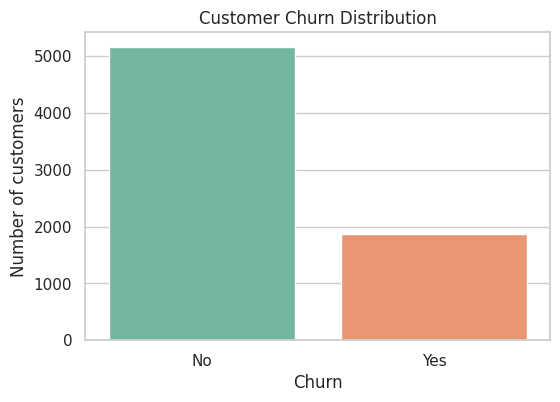

,Churn,Count,Percent
0,No,5163,0.734215
1,Yes,1869,0.265785


In [20]:
# Plot how many customers are in each churn group.

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="Churn", hue="Churn", palette="Set2", legend=False, ax=ax)
ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of customers")
plt.show()

churn_summary

In [21]:
# Compare basic numeric summaries for customers who churned vs stayed.

df.groupby("Churn")[numeric_features].agg(["mean", "median", "std"]).round(2)

SeniorCitizen              tenure               MonthlyCharges         \
               mean median   std   mean median    std           mean median   
Churn                                                                         
No             0.13    0.0  0.34  37.65   38.0  24.08          61.31  64.45   
Yes            0.25    0.0  0.44  17.98   10.0  19.53          74.44  79.65   

             TotalCharges                    
         std         mean   median      std  
Churn                                        
No     31.09      2555.34  1683.60  2329.46  
Yes    24.67      1531.80   703.55  1890.82

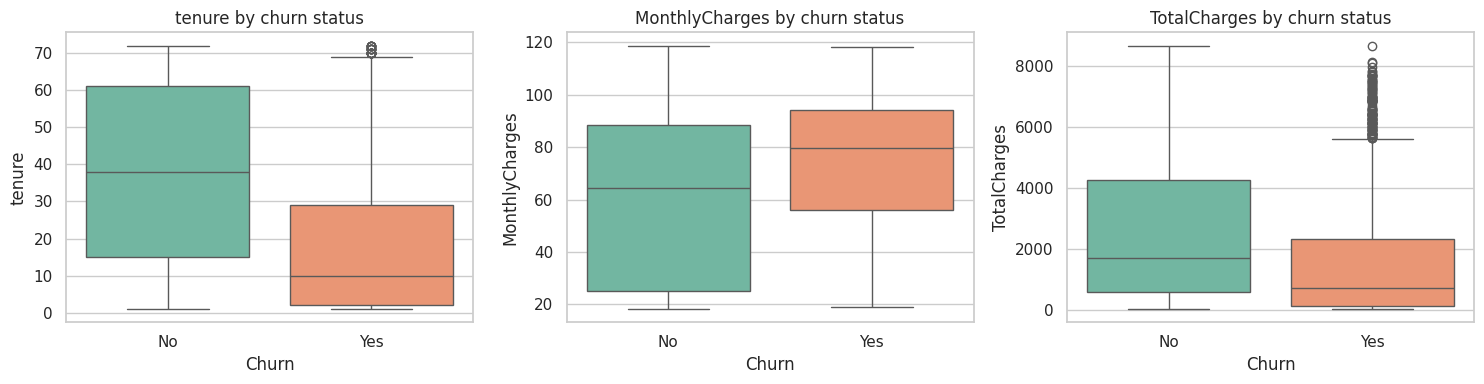

In [22]:
# Plot the continuous numeric features for churned vs non-churned customers.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, continuous_features):
    sns.boxplot(data=df, x="Churn", y=feature, hue="Churn", palette="Set2", legend=False, ax=ax)
    ax.set_title(f"{feature} by churn status")
    ax.set_xlabel("Churn")

plt.tight_layout()
plt.show()

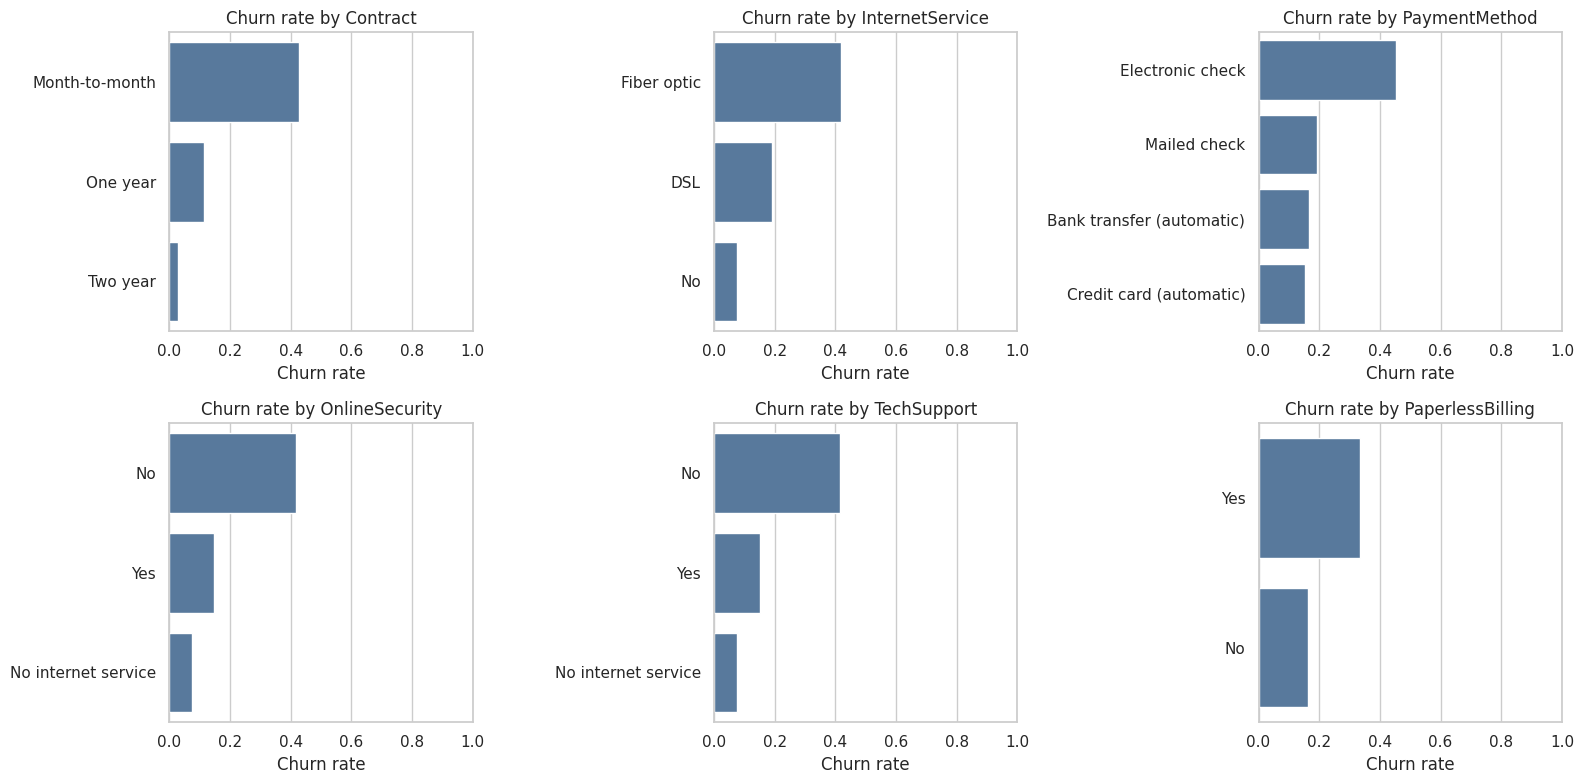

In [23]:
# Plot churn rate for selected categorical columns.

key_categorical_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, feature in zip(axes, key_categorical_features):
    churn_rate = (
        df.groupby(feature)["ChurnBinary"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    sns.barplot(data=churn_rate, x="ChurnBinary", y=feature, color="#4C78A8", ax=ax)
    ax.set_title(f"Churn rate by {feature}")
    ax.set_xlabel("Churn rate")
    ax.set_ylabel("")
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

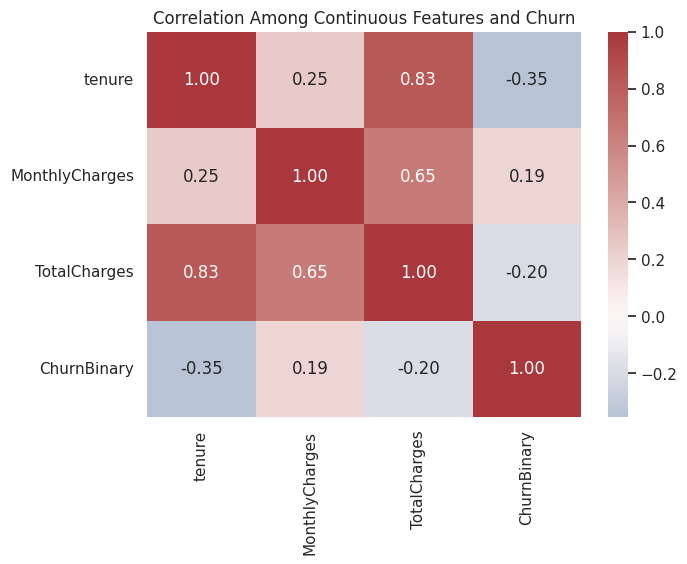

,ChurnBinary
ChurnBinary,1.000000
MonthlyCharges,0.192858
TotalCharges,-0.199484
tenure,-0.354049


In [24]:
# Check correlations between continuous features and churn.

corr_columns = continuous_features + [target]
corr = df[corr_columns].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="vlag", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation Among Continuous Features and Churn")
plt.show()

corr[target].sort_values(ascending=False)

## 6. Assumption Checks

This section creates evidence for the README assumption table. The goal is to check where each model seems reasonable and where we should be careful.

### 6.1 Prepare Encoded Design Matrix

Linear regression and logistic regression cannot accept text labels. This step turns categories into encoded numerical columns and scales the numeric columns.

In [25]:
# Transform the training and test features into numeric model-ready tables.

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

if hasattr(X_train_encoded, "toarray"):
    X_train_encoded = X_train_encoded.toarray()
    X_test_encoded = X_test_encoded.toarray()

encoded_feature_names = preprocessor.get_feature_names_out()
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test.index)

print(f"Encoded training shape: {X_train_encoded_df.shape}")
X_train_encoded_df.head()

Encoded training shape: (5625, 30)


,numeric__SeniorCitizen,numeric__tenure,numeric__MonthlyCharges,numeric__TotalCharges,categorical__gender_Male,categorical__Partner_Yes,categorical__Dependents_Yes,categorical__PhoneService_Yes,categorical__MultipleLines_No phone service,categorical__MultipleLines_Yes,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__OnlineSecurity_No internet service,categorical__OnlineSecurity_Yes,categorical__OnlineBackup_No internet service,categorical__OnlineBackup_Yes,categorical__DeviceProtection_No internet service,categorical__DeviceProtection_Yes,categorical__TechSupport_No internet service,categorical__TechSupport_Yes,categorical__StreamingTV_No internet service,categorical__StreamingTV_Yes,categorical__StreamingMovies_No internet service,categorical__StreamingMovies_Yes,categorical__Contract_One year,categorical__Contract_Two year,categorical__PaperlessBilling_Yes,categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check
1413,-0.439319,1.321816,0.981556,1.659900,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
7003,-0.439319,-0.267410,-0.971546,-0.562252,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3355,-0.439319,1.444064,0.837066,1.756104,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4494,-0.439319,-1.204646,0.641092,-0.908326,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3541,-0.439319,0.669826,-0.808787,-0.101561,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 6.2 Multicollinearity

Checking for overlapping predictors.

In [26]:
# Calculate VIF scores to see which encoded predictors overlap with each other.

import warnings
from statsmodels.tools.sm_exceptions import SingularMatrixWarning

vif_matrix = sm.add_constant(X_train_encoded_df)
vif_values = []

# Hide warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    warnings.simplefilter("ignore", category=RuntimeWarning)
    warnings.simplefilter("ignore", category=SingularMatrixWarning)

    for i, column in enumerate(vif_matrix.columns):
        if column == "const":
            continue
        vif_values.append({
            "feature": column,
            "VIF": variance_inflation_factor(vif_matrix.values, i),
        })

vif_df = pd.DataFrame(vif_values).sort_values("VIF", ascending=False)
vif_df["multicollinearity_flag"] = np.select(
    [np.isinf(vif_df["VIF"]), vif_df["VIF"] >= 10, vif_df["VIF"] >= 5],
    ["Perfect/redundant", "High", "Moderate"],
    default="Low",
)

print(f"Features with infinite VIF: {np.isinf(vif_df['VIF']).sum()}")
print(f"Features with VIF >= 10: {(vif_df['VIF'] >= 10).sum()}")
vif_df.head(15)

Features with infinite VIF: 2
Features with VIF >= 10: 14


,feature,VIF,multicollinearity_flag
8,categorical__MultipleLines_No phone service,inf,Perfect/redundant
7,categorical__PhoneService_Yes,inf,Perfect/redundant
11,categorical__InternetService_No,6.528352e+09,High
12,categorical__OnlineSecurity_No internet service,6.528352e+09,High
22,categorical__StreamingMovies_No internet service,2.050829e+09,High
18,categorical__TechSupport_No internet service,4.941860e+08,High
16,categorical__DeviceProtection_No internet service,3.402171e+08,High
20,categorical__StreamingTV_No internet service,1.330427e+08,High
14,categorical__OnlineBackup_No internet service,1.270910e+08,High
2,numeric__MonthlyCharges,7.880450e+02,High


### 6.3 Linear Regression Assumptions

Multicolinearity (see above), normality of residuals, linearity, and homoscedacisity evaluated. Indepenence assumed since each row is a single customer.

In [27]:
# Fit the assignment-required linear regression model and calculate its errors.

ols_model = sm.OLS(y_train, sm.add_constant(X_train_encoded_df)).fit()
linear_train_pred = ols_model.predict(sm.add_constant(X_train_encoded_df))
linear_residuals = y_train - linear_train_pred

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            ChurnBinary   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.286
Method:                 Least Squares   F-statistic:                     99.17
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:37:30   Log-Likelihood:                -2425.0
No. Observations:                5625   AIC:                             4898.
Df Residuals:                    5601   BIC:                             5057.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

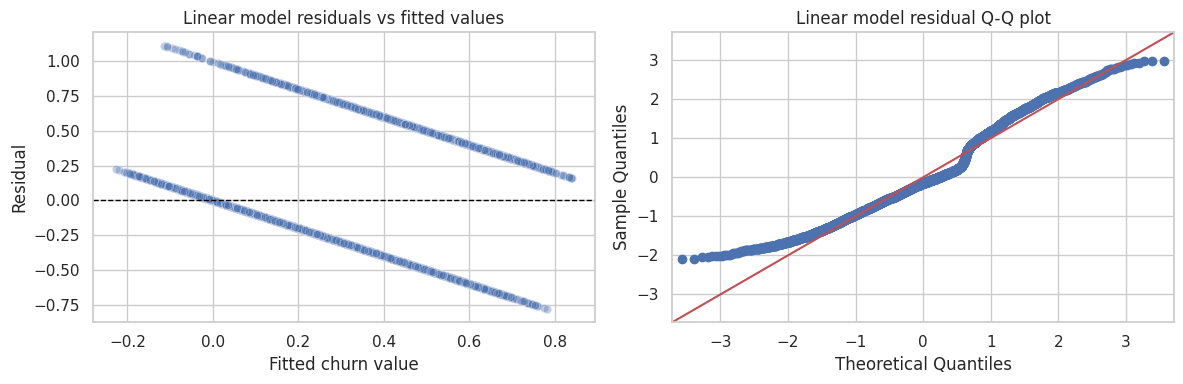

In [28]:
# Plot the linear regression errors to check for patterns.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(x=linear_train_pred, y=linear_residuals, alpha=0.35, ax=axes[0])
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Linear model residuals vs fitted values")
axes[0].set_xlabel("Fitted churn value")
axes[0].set_ylabel("Residual")

sm.qqplot(linear_residuals, line="45", fit=True, ax=axes[1])
axes[1].set_title("Linear model residual Q-Q plot")

plt.tight_layout()
plt.show()

In [29]:
# Run two formal checks for the linear regression assumption section.

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=SingularMatrixWarning)
    warnings.simplefilter("ignore", category=UserWarning)

    bp_stat, bp_pvalue, f_stat, f_pvalue = het_breuschpagan(
        linear_residuals,
        sm.add_constant(X_train_encoded_df),
    )

    reset_result = linear_reset(ols_model, power=2, use_f=True)

linear_assumption_results = pd.DataFrame({
    "check": ["Breusch-Pagan heteroscedasticity", "RESET functional form"],
    "statistic": [bp_stat, float(reset_result.fvalue)],
    "p_value": [bp_pvalue, float(reset_result.pvalue)],
    "note": [
        "Uses linear model residuals and encoded predictors.",
        "Uses fitted OLS model to test for omitted nonlinear terms.",
    ],
})
linear_assumption_results

,check,statistic,p_value,note
0,Breusch-Pagan heteroscedasticity,1094.769525,4.794446e-211,Uses linear model residuals and encoded predic...
1,RESET functional form,178.932926,3.412378e-40,Uses fitted OLS model to test for omitted nonl...


### 6.4 Logistic Regression Assumptions

Logistic regression fits this problem more naturally because churn is yes/no. Here we validate the target is binary, whether we have enough churn cases, whether any categories perfectly predict churn, and whether continuous features look roughly linear on the log-odds scale.

In [30]:
# Count churn cases and predictors to check whether logistic regression has enough event data.

n_events = int(y_train.sum())
n_predictors = X_train_encoded_df.shape[1]
events_per_predictor = n_events / n_predictors

pd.DataFrame({
    "diagnostic": ["Unique target values", "Churn events in training", "Encoded predictors", "Events per predictor"],
    "value": [sorted(y_train.unique()), n_events, n_predictors, round(events_per_predictor, 1)],
})

,diagnostic,value
0,Unique target values,"[0, 1]"
1,Churn events in training,1495
2,Encoded predictors,30
3,Events per predictor,49.8


In [31]:
# Check category levels for tiny groups or levels that perfectly predict churn.

separation_checks = []

for feature in categorical_features:
    grouped = df.groupby(feature)[target].agg(["count", "mean"]).reset_index()
    grouped["feature"] = feature
    grouped = grouped.rename(columns={feature: "level", "mean": "churn_rate"})
    separation_checks.append(grouped[["feature", "level", "count", "churn_rate"]])

separation_df = pd.concat(separation_checks, ignore_index=True)
separation_df["possible_separation_or_sparse_level"] = (
    (separation_df["churn_rate"].isin([0, 1])) | (separation_df["count"] < 30)
)

separation_df.sort_values(
    ["possible_separation_or_sparse_level", "churn_rate"],
    ascending=[False, False],
).head(20)

,feature,level,count,churn_rate,possible_separation_or_sparse_level
39,PaymentMethod,Electronic check,2365,0.452854,False
32,Contract,Month-to-month,3875,0.427097,False
12,InternetService,Fiber optic,3096,0.418928,False
14,OnlineSecurity,No,3497,0.417787,False
23,TechSupport,No,3472,0.416475,False
17,OnlineBackup,No,3087,0.399417,False
20,DeviceProtection,No,3094,0.391403,False
29,StreamingMovies,No,2781,0.337289,False
36,PaperlessBilling,Yes,4168,0.335893,False
26,StreamingTV,No,2809,0.335351,False


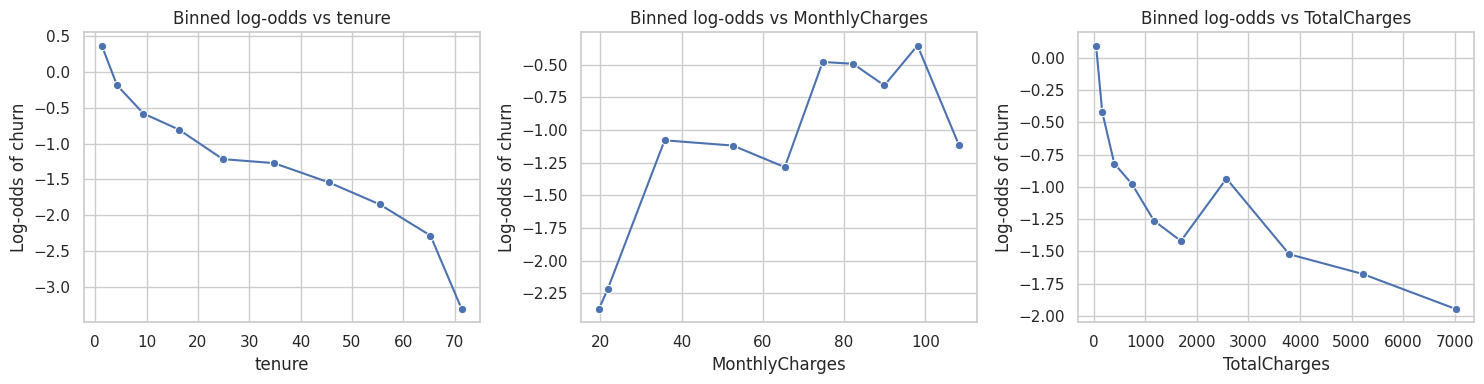

In [32]:
# Bin continuous features and plot their relationship with churn log-odds.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, continuous_features):
    binned = pd.DataFrame({feature: df[feature], target: df[target]})
    binned["bin"] = pd.qcut(binned[feature], q=10, duplicates="drop")
    rates = binned.groupby("bin", observed=True).agg(
        feature_midpoint=(feature, "mean"),
        churn_rate=(target, "mean"),
        count=(target, "size"),
    ).reset_index()
    rates["churn_rate_clipped"] = rates["churn_rate"].clip(0.001, 0.999)
    rates["log_odds"] = logit(rates["churn_rate_clipped"])

    sns.lineplot(data=rates, x="feature_midpoint", y="log_odds", marker="o", ax=ax)
    ax.set_title(f"Binned log-odds vs {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Log-odds of churn")

plt.tight_layout()
plt.show()

### 6.5 GAM Assumption Considerations

A GAM lets continuous features have curved effects vs forcing straight-line effects. Before fitting, we validate whether `tenure`, `MonthlyCharges`, and `TotalCharges` contain enough data across their ranges to support those curves.

In [33]:
# Check the range and bin coverage for continuous features before using them in a GAM.

gam_numeric_profile = []

for feature in continuous_features:
    binned = pd.DataFrame({feature: df[feature], target: df[target]})
    binned["bin"] = pd.qcut(binned[feature], q=10, duplicates="drop")
    bin_counts = binned.groupby("bin", observed=True).size()

    gam_numeric_profile.append({
        "feature": feature,
        "min": df[feature].min(),
        "q25": df[feature].quantile(0.25),
        "median": df[feature].median(),
        "q75": df[feature].quantile(0.75),
        "max": df[feature].max(),
        "unique_values": df[feature].nunique(),
        "number_of_bins": bin_counts.shape[0],
        "smallest_bin_count": bin_counts.min(),
        "largest_bin_count": bin_counts.max(),
    })

pd.DataFrame(gam_numeric_profile)

,feature,min,q25,median,q75,max,unique_values,number_of_bins,smallest_bin_count,largest_bin_count
0,tenure,1.00,9.0000,29.000,55.0000,72.00,72,10,619,851
1,MonthlyCharges,18.25,35.5875,70.350,89.8625,118.75,1584,10,694,714
2,TotalCharges,18.80,401.4500,1397.475,3794.7375,8684.80,6530,10,702,705


## 7. Linear Regression Model

In [35]:
# Fit linear regression and evaluate it on the test set.

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression()),
])

linear_model.fit(X_train, y_train)
linear_test_pred = linear_model.predict(X_test)
linear_test_class = (linear_test_pred >= 0.5).astype(int)

linear_metrics = {
    "Model": "Linear regression",
    "R2": r2_score(y_test, linear_test_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, linear_test_pred)),
    "MAE": mean_absolute_error(y_test, linear_test_pred),
    "ROC_AUC": roc_auc_score(y_test, linear_test_pred),
    "Accuracy": accuracy_score(y_test, linear_test_class),
    "Precision": precision_score(y_test, linear_test_class),
    "Recall": recall_score(y_test, linear_test_class),
    "F1": f1_score(y_test, linear_test_class),
    "Min_Prediction": linear_test_pred.min(),
    "Max_Prediction": linear_test_pred.max(),
}

pd.DataFrame([linear_metrics]).round(3)

,Model,R2,RMSE,MAE,ROC_AUC,Accuracy,Precision,Recall,F1,Min_Prediction,Max_Prediction
0,Linear regression,0.26,0.38,0.302,0.828,0.795,0.638,0.532,0.58,-0.192,0.828


In [36]:
# Show the largest linear regression coefficients by absolute size.

linear_feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
linear_coef_df = pd.DataFrame({
    "feature": linear_feature_names,
    "coefficient": linear_model.named_steps["model"].coef_,
})
linear_coef_df["abs_coefficient"] = linear_coef_df["coefficient"].abs()

linear_coef_df.sort_values("abs_coefficient", ascending=False).head(12)

,feature,coefficient,abs_coefficient
10,categorical__InternetService_Fiber optic,0.322161,0.322161
2,numeric__MonthlyCharges,-0.174622,0.174622
24,categorical__Contract_One year,-0.116767,0.116767
21,categorical__StreamingTV_Yes,0.112484,0.112484
23,categorical__StreamingMovies_Yes,0.111554,0.111554
3,numeric__TotalCharges,-0.102588,0.102588
9,categorical__MultipleLines_Yes,0.086748,0.086748
25,categorical__Contract_Two year,-0.082743,0.082743
28,categorical__PaymentMethod_Electronic check,0.075946,0.075946
14,categorical__OnlineBackup_No internet service,-0.041645,0.041645


## 8. Logistic Regression Model

In [37]:
# Fit logistic regression and evaluate churn probability predictions.

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])

logistic_model.fit(X_train, y_train)
logistic_test_prob = logistic_model.predict_proba(X_test)[:, 1]
logistic_test_class = (logistic_test_prob >= 0.5).astype(int)

logistic_metrics = {
    "Model": "Logistic regression",
    "ROC_AUC": roc_auc_score(y_test, logistic_test_prob),
    "Accuracy": accuracy_score(y_test, logistic_test_class),
    "Precision": precision_score(y_test, logistic_test_class),
    "Recall": recall_score(y_test, logistic_test_class),
    "F1": f1_score(y_test, logistic_test_class),
}

pd.DataFrame([logistic_metrics]).round(3)

,Model,ROC_AUC,Accuracy,Precision,Recall,F1
0,Logistic regression,0.836,0.805,0.652,0.575,0.611


In [38]:
# Show the logistic regression confusion matrix.

logistic_confusion = pd.DataFrame(
    confusion_matrix(y_test, logistic_test_class),
    index=["Actual stayed", "Actual churned"],
    columns=["Predicted stayed", "Predicted churned"],
)
logistic_confusion

,Predicted stayed,Predicted churned
Actual stayed,918,115
Actual churned,159,215


In [39]:
# Convert logistic regression coefficients to odds ratios for interpretation.

logistic_feature_names = logistic_model.named_steps["preprocessor"].get_feature_names_out()
logistic_coef_df = pd.DataFrame({
    "feature": logistic_feature_names,
    "coefficient": logistic_model.named_steps["model"].coef_[0],
})
logistic_coef_df["odds_ratio"] = np.exp(logistic_coef_df["coefficient"])
logistic_coef_df["abs_coefficient"] = logistic_coef_df["coefficient"].abs()

logistic_coef_df.sort_values("abs_coefficient", ascending=False).head(12)

,feature,coefficient,odds_ratio,abs_coefficient
25,categorical__Contract_Two year,-1.364823,0.255426,1.364823
1,numeric__tenure,-1.357404,0.257328,1.357404
10,categorical__InternetService_Fiber optic,1.107407,3.026501,1.107407
24,categorical__Contract_One year,-0.750068,0.472334,0.750068
3,numeric__TotalCharges,0.645508,1.906955,0.645508
7,categorical__PhoneService_Yes,-0.515337,0.597299,0.515337
2,numeric__MonthlyCharges,-0.434497,0.647591,0.434497
28,categorical__PaymentMethod_Electronic check,0.379150,1.461042,0.379150
13,categorical__OnlineSecurity_Yes,-0.373187,0.688536,0.373187
21,categorical__StreamingTV_Yes,0.372407,1.451224,0.372407


## 9. GAM Model

In [40]:
# Build a GAM-ready feature table with continuous features first.

X_gam = pd.concat([
    df[continuous_features + binary_features],
    pd.get_dummies(df[categorical_features], drop_first=True, dtype=float),
], axis=1)

X_gam_train, X_gam_test, y_gam_train, y_gam_test = train_test_split(
    X_gam,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

X_gam.head()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,34,56.95,1889.50,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,2,53.85,108.15,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,45,42.30,1840.75,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2,70.70,151.65,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [41]:
# Fit a logistic GAM with smooth terms for the continuous features.

gam_terms = s(0) + s(1) + s(2)
for column_index in range(3, X_gam.shape[1]):
    gam_terms = gam_terms + l(column_index)

gam_model = LogisticGAM(gam_terms, max_iter=200).fit(
    X_gam_train.values,
    y_gam_train.values,
)

gam_test_prob = gam_model.predict_proba(X_gam_test.values)
gam_test_class = (gam_test_prob >= 0.5).astype(int)

gam_metrics = {
    "Model": "GAM",
    "ROC_AUC": roc_auc_score(y_gam_test, gam_test_prob),
    "Accuracy": accuracy_score(y_gam_test, gam_test_class),
    "Precision": precision_score(y_gam_test, gam_test_class),
    "Recall": recall_score(y_gam_test, gam_test_class),
    "F1": f1_score(y_gam_test, gam_test_class),
}

pd.DataFrame([gam_metrics]).round(3)

,Model,ROC_AUC,Accuracy,Precision,Recall,F1
0,GAM,0.841,0.797,0.638,0.543,0.587


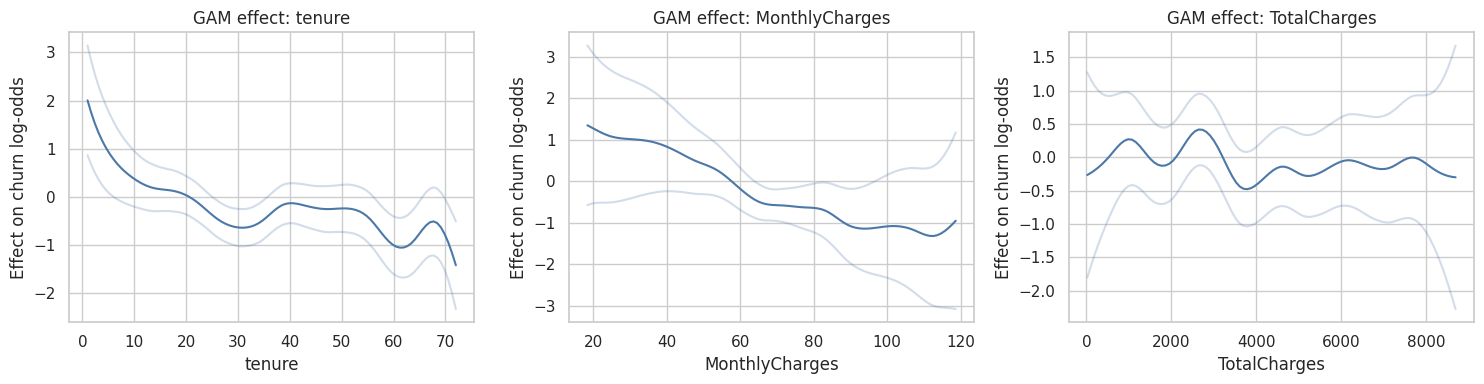

In [42]:
# Plot the GAM smooth effects for the continuous features.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for term_index, ax in enumerate(axes):
    grid = gam_model.generate_X_grid(term=term_index)
    partial_dependence = gam_model.partial_dependence(term=term_index, X=grid)
    confidence_intervals = gam_model.partial_dependence(term=term_index, X=grid, width=0.95)[1]

    ax.plot(grid[:, term_index], partial_dependence, color="#4C78A8")
    ax.plot(grid[:, term_index], confidence_intervals, color="#4C78A8", alpha=0.25)
    ax.set_title(f"GAM effect: {continuous_features[term_index]}")
    ax.set_xlabel(continuous_features[term_index])
    ax.set_ylabel("Effect on churn log-odds")

plt.tight_layout()
plt.show()

In [43]:
# Show the GAM confusion matrix.

gam_confusion = pd.DataFrame(
    confusion_matrix(y_gam_test, gam_test_class),
    index=["Actual stayed", "Actual churned"],
    columns=["Predicted stayed", "Predicted churned"],
)
gam_confusion

,Predicted stayed,Predicted churned
Actual stayed,918,115
Actual churned,171,203


## 10. Model Comparison

This table puts the model results in one place. ROC-AUC is useful here because it compares how well the models rank customers by churn risk.

In [44]:
# Compare the test-set performance of the three models.

model_comparison = pd.DataFrame([
    linear_metrics,
    logistic_metrics,
    gam_metrics,
])

display_columns = ["Model", "ROC_AUC", "Accuracy", "Precision", "Recall", "F1"]
model_comparison[display_columns].round(3)

,Model,ROC_AUC,Accuracy,Precision,Recall,F1
0,Linear regression,0.828,0.795,0.638,0.532,0.580
1,Logistic regression,0.836,0.805,0.652,0.575,0.611
2,GAM,0.841,0.797,0.638,0.543,0.587


## 11. Recommendation Draft

Based on these models, I would recommend logistic regression as the main model for the company. It fits the yes/no churn outcome, performs almost as well as the GAM, and is easier to explain to business users through odds ratios. The GAM is still useful as a follow-up interpretability tool for checking curved effects in tenure and charges.

See the README for summaries of the assumption checks, comparisson of the three models, and full explaination of the recommendation.